In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

#plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore missing font warnings from seaborn
warnings.filterwarnings("ignore", module="matplotlib.font_manager")


sim_type = Ball3StickSharedDiffusivity
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

In [3]:
from dmri.simulators.acquisition_scheme import acquisition_scheme, random_hcp_acquisition


@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    acq = random_hcp_acquisition(rng)


    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))
    rng_p, rng_m = jax.random.split(rng2)
    p_mask = jax.random.beta(rng_p, a=1, b=1, shape=(1,))
    #model_mask = jax.random.bernoulli(rng_m, p=p_mask, shape=(len(sim_type.model_types)))
    model_mask = jnp.ones(len(sim_type.model_types), dtype=jnp.bool)
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(sim_type.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(sim_type.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(acq, rng=rng5)

    def posterior_score(theta, x):
        ball_stick = sim_type.from_theta(theta, model_mask=model_mask)
        ll = ball_stick.log_likelihood(acq, x)
        prior = jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)
        return ll + prior

    score = jax.grad(posterior_score)(theta, x_o)
    return p_mask, model_mask, theta, x_o, acq, score


In [4]:
p_mask,masks, theta, x_o, acq, score= jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

In [5]:
(score**2).sum(-1).mean()

Array(97422.125, dtype=float32)

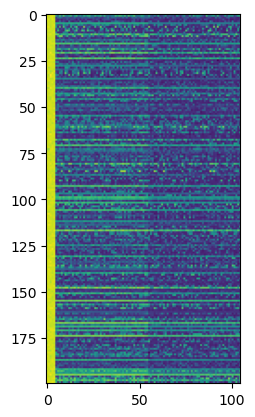

In [6]:
import matplotlib.pyplot as plt
plt.imshow(x_o)

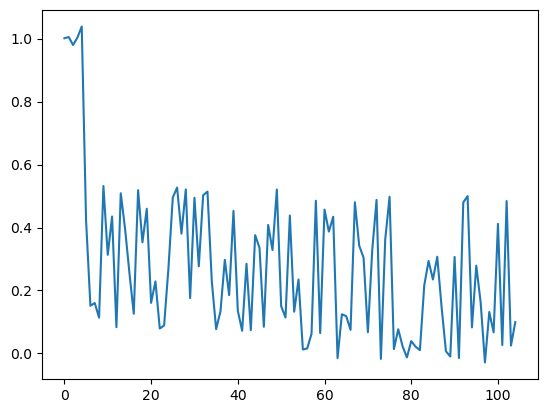

In [7]:
plt.plot(x_o[6])

In [82]:
from dmri.nn.simformer import EDMSimformer
from dmri.nn.tokenizer import ScalarTokenizer
from dmri.nn.embedding_net import BvalBvecSignalEmbeddingNet


from probjax.nn.nets import Transformer
from probjax.nn import GaussianFourierEmbedding, MLP
from probjax.nn.nets.denoising_diffusion_model import EDM

In [84]:
class Model(nnx.Module):
    def __init__(self, rngs):
        self.tokenizer = ScalarTokenizer(11, rngs=rngs, id_dim=64, value_dim=64, cond_dim=0)
        self.time_embedding = GaussianFourierEmbedding(1,64, rngs=rngs)
        self.transformer = Transformer(128, 4, 4, 16,rngs=rngs, context_dim=64)
        self.signal_embedding = MLP([1,128,128], rngs=rngs)
        self.output_layer = MLP([128,128,1], rngs=rngs)

    def  __call__(self, t, x, y=None, context=None, attention_mask=None, **kwargs):
        tokens = self.tokenizer(x[...,None], jnp.arange(11)[None,...].repeat(x.shape[0], axis=0), None)
        y = self.signal_embedding(y[...,None])
        all_tokens = jnp.concatenate([tokens, y], axis=-2)
        t = self.time_embedding(t)
        context = t
        output = self.transformer(all_tokens, context=context, mask=attention_mask)
        return self.output_layer(output[...,:11,:])[...,0]

model = EDM(Model(nnx.Rngs(0)))


In [85]:
import optax

#scheduler = optax.cosine_onecycle_schedule(100*500, 5e-4)
optimizer = optax.chain(optax.adam(5e-4))

params = nnx.state(model, nnx.Param)
opt_state = optimizer.init(params)


In [86]:
from dmri.train.dataloader import StreamDataLoader

dataloader = StreamDataLoader(simulator, batch_size=1024, num_producers=1)

In [87]:
dataloader.queue_size()

0

In [88]:
datastream = iter(dataloader)

In [89]:

def loss_fn(params, data, rng):
    nnx.update(model, params)
    p_mask, model_mask, thetas,  xs, acq, score = data
    bvals = acq.bvals
    bvecs = acq.bvecs
    rng1, rng2 = jax.random.split(rng)
    loss = model.loss(rng1, thetas, y=xs)
    # rng_t, rng_score = jax.random.split(rng2)
    # ts = jax.random.uniform(rng_t, (thetas.shape[0],1))*0.01 + 0.001

    # thetas_noisy = thetas + jax.random.normal(rng_score, thetas.shape)*ts
    # score_estimate = model.score(ts, thetas_noisy, y=xs)
    # score_loss = ts * (score_estimate - score)**2
    # loss = loss + score_loss.mean()

    return loss


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [90]:
# Initialize EMA parameters
ema_decay = 0.99
ema_params = jax.tree_map(lambda x: x.copy(), params)

data_stream = iter(dataloader)
for i in range(100):
    key = jax.random.PRNGKey(i)
    l = 0
    for j in range(500):
        key, subkey2 = jax.random.split(key, 2)
        x = next(data_stream)
        params, opt_state, loss = update(params, opt_state, x, subkey2)

        # Update EMA parameters
        ema_params = jax.tree_map(
            lambda ema, p: ema * ema_decay + p * (1 - ema_decay),
            ema_params,
            params
        )

        l += loss
    print(l/500)

10.601522
9.459088
9.215074
9.149049
9.114828
9.078116
9.058447
9.0175495
9.006418
8.980544
8.97871
8.964451
8.965582
8.960129
8.951781
8.954394
8.934078
8.943334
8.9330225


KeyboardInterrupt: 

Array(20315.53, dtype=float32)

In [91]:
nnx.update(model, ema_params)

In [92]:
batch_simulator = jax.jit(jax.vmap(simulator))
p_mask, masks, thetas, x_os, acq, score = batch_simulator(jax.random.split(jax.random.key(0), 100))

In [93]:
score_approx = model.score(jnp.ones((100,1))*0.005, thetas, y=x_os)

In [94]:
jnp.mean((score_approx - score)**2)
#idx = 2

Array(11569.872, dtype=float32)

In [95]:
# Compute cosine similarity between score and score_approx
cosine_similarity = jnp.sum(score * score_approx, axis=-1) / (jnp.linalg.norm(score, axis=-1) * jnp.linalg.norm(score_approx, axis=-1))
jnp.mean(cosine_similarity)


Array(0.146, dtype=float32)

In [96]:
#idx = 2
idx = 12


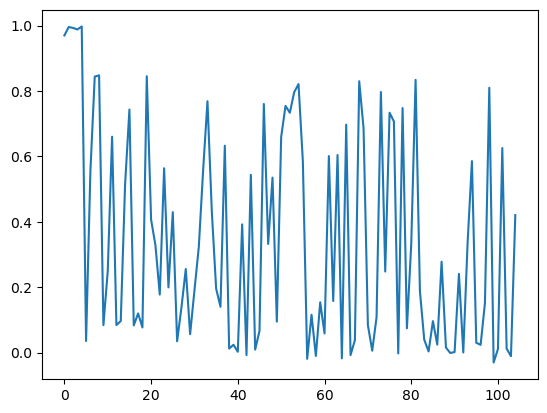

In [97]:
plt.plot(x_os[idx])

In [98]:
from probjax.utils.odeint import odeint


def sample(rng, context):
    eps = jax.random.normal(rng, (11,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(200)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t[None],x[None], y=context[None])[0]
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")[-1]

In [79]:
from functools import partial
thetas_post = jax.vmap(partial(sample, context=x_os[idx]))(jax.random.split(jax.random.key(0), 4096))

In [80]:
thetas_post.shape

(4096, 11)

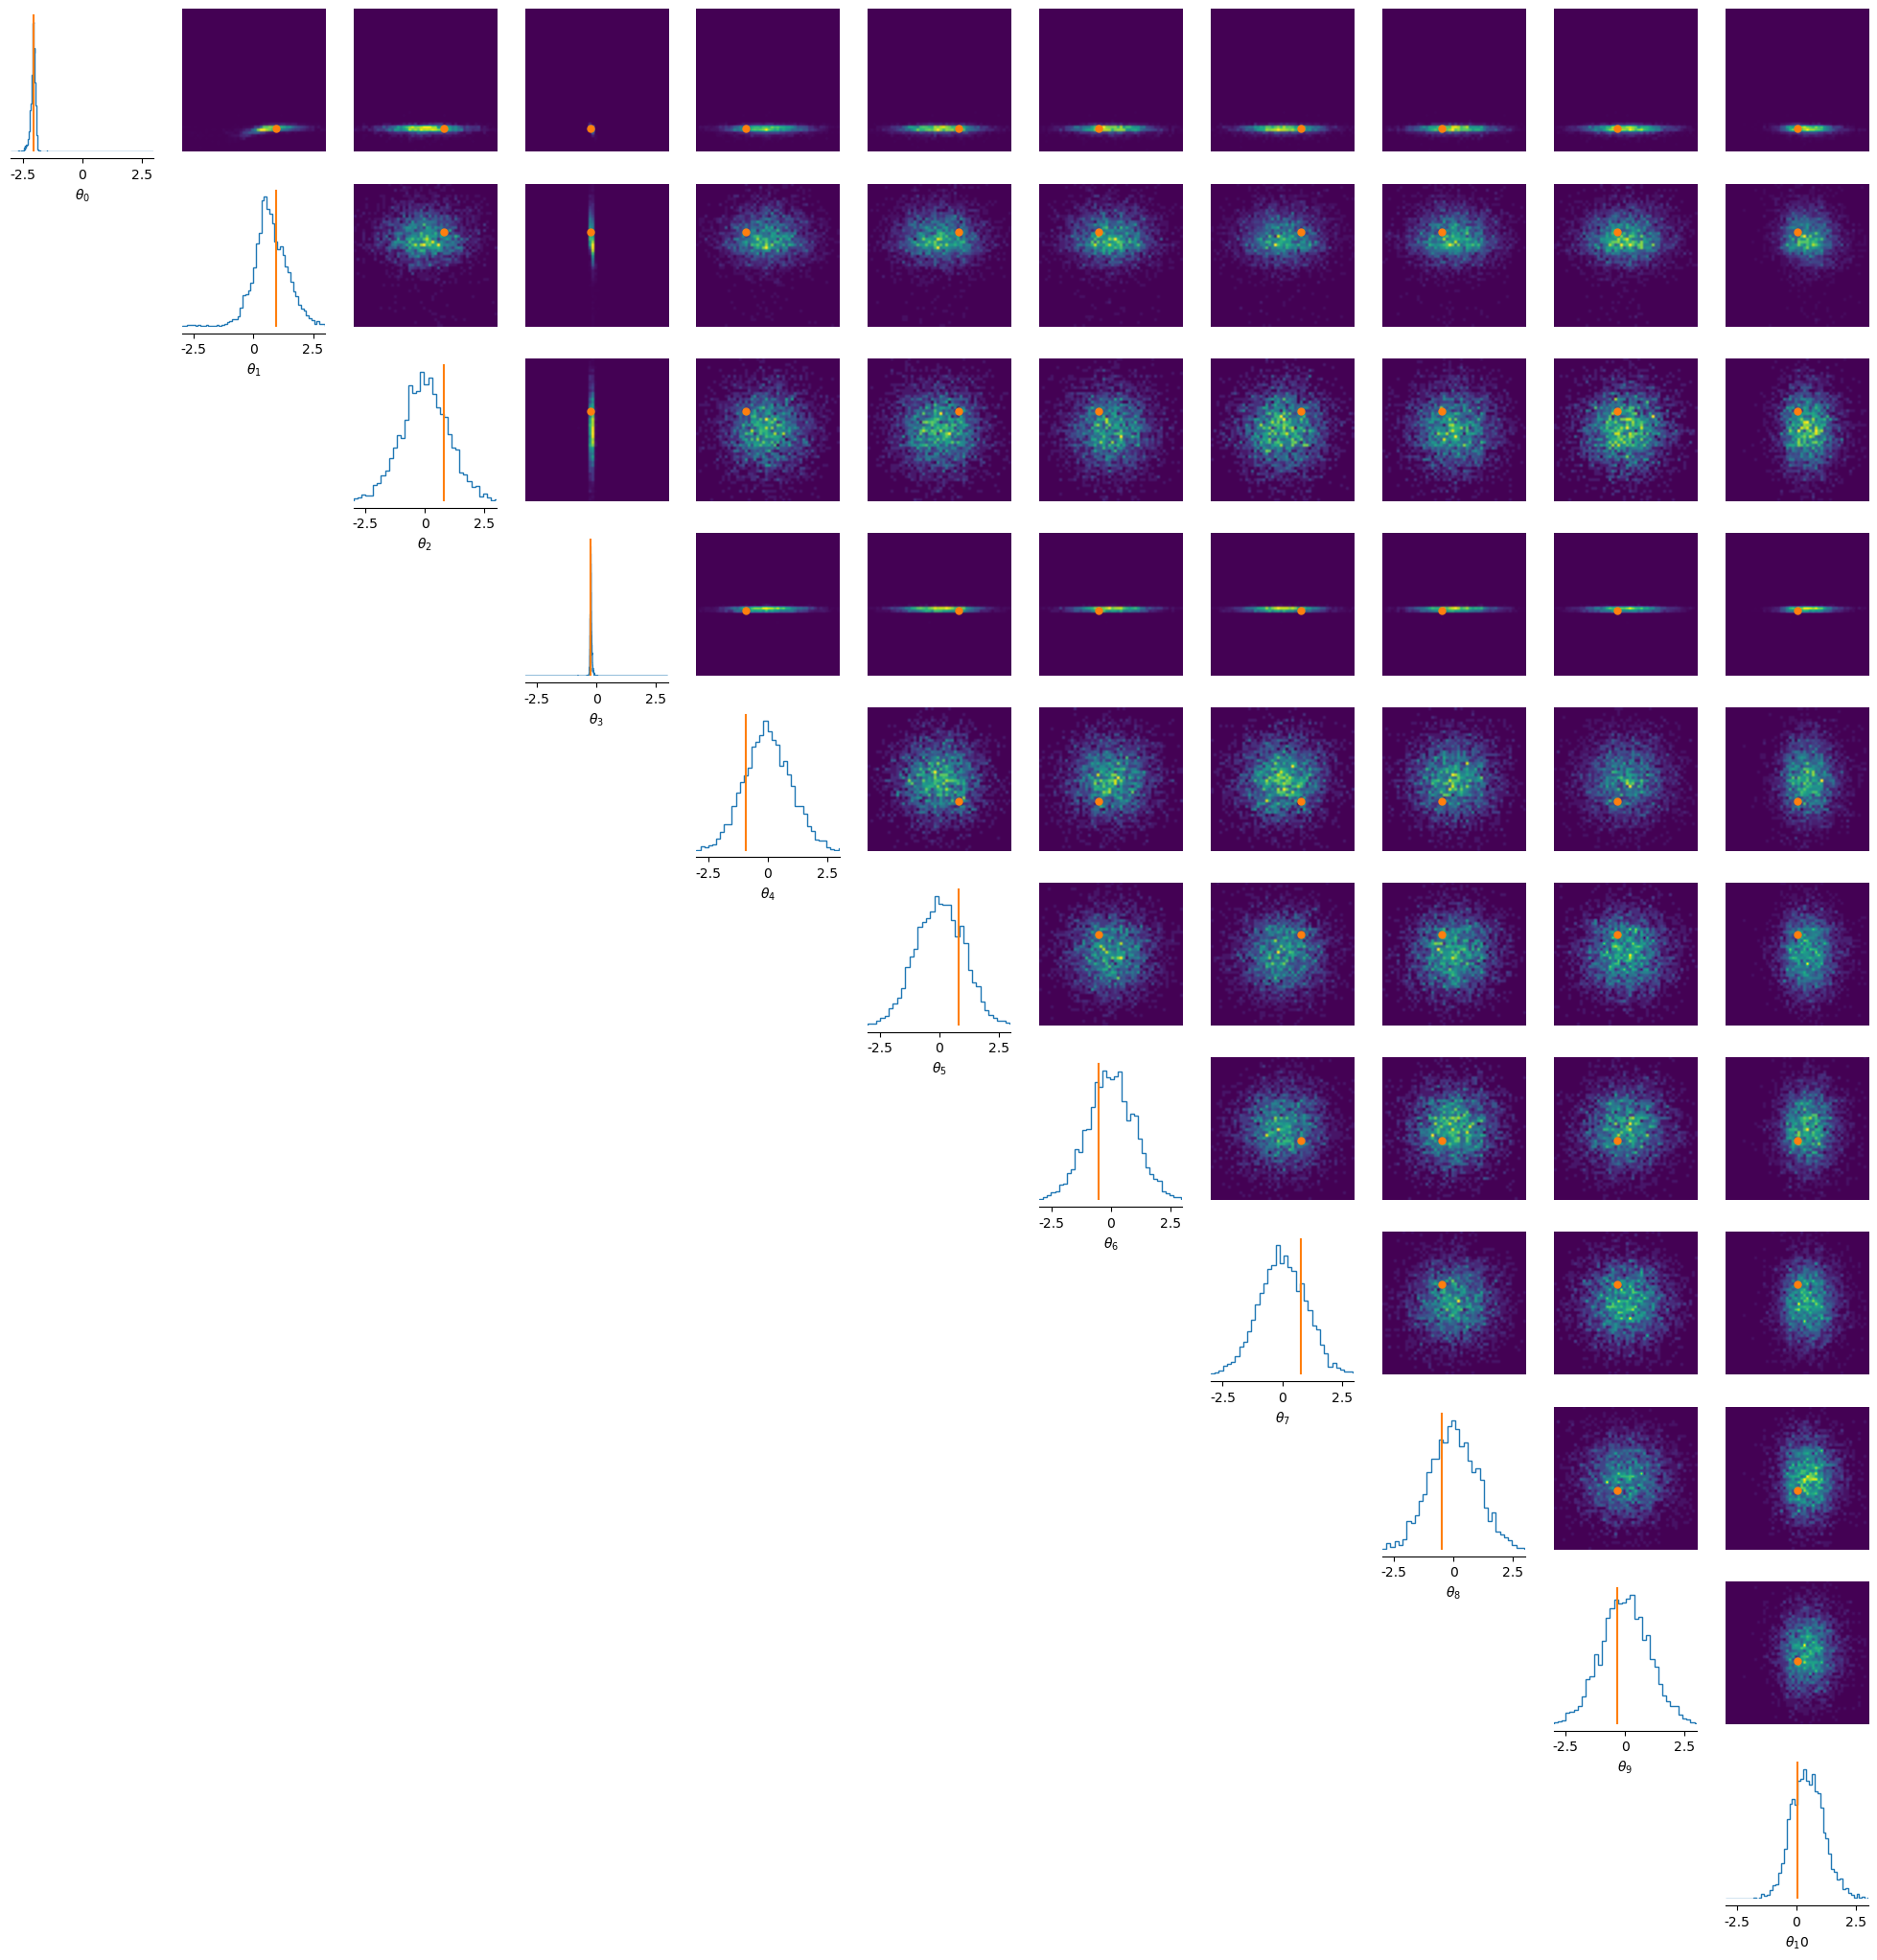

In [81]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [67]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def loglikelihood(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 4096))

Text(0, 0.5, 'MRI Signal')

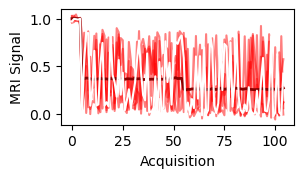

In [68]:
bvals = acq.bvals[idx]
bvecs = acq.bvecs[idx]
sort_bvals = jnp.argsort(bvals)
bvals = bvals[sort_bvals]
posterior_preds_sorted = posterior_preds[:,sort_bvals]
x_o = x_os[idx][sort_bvals]


fig = plt.figure(figsize=(3, 1.5))

_ = plt.plot(posterior_preds_sorted[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds_sorted.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

In [52]:
def loglikelihood(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_posterior(theta, mask, acq, x):
    theta_mask = model.tokenizer.theta_mask(mask)
    return loglikelihood(theta, mask, acq, x) + (theta_mask*jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)).sum()

def log_q(theta, mask, acq, x):
    return model.log_prob_theta(theta, acq.bvals, acq.bvecs, x, num_steps=512, max_noise=80, model_mask=mask)

@jax.grad
def true_score(theta, mask, acq, x):
    return log_posterior(theta, mask, acq, x).sum()


@jax.jit
def effectve_sample_size(thetas):
    logp = jax.vmap(partial(log_posterior, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    logq = jax.vmap(partial(log_q, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    log_w = logp - logq
    # Self normalized importance weights
    w = jax.nn.softmax(log_w)
    return 1/jnp.sum(w**2)


In [53]:
effectve_sample_size(thetas_post)

Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


Array(1.003, dtype=float32)